## **ECE 226: Optimize&Accelerate/Platforms, Winter 2025, UCSD**
## **Lab 3: Deployment on MCU and Knowledge Distillation**
### **Instructor: Prof. Farinaz Koushanfar**
### **Due: Sunday, Feb 8, 2025, 11:59 PM**

## Instructions

- This notebook contains two setup scripts, one for DataHub and one for Google Colab. Feel free to use either to complete this assignment
- Review the academic integrity and collaboration policies.
- This assignment must be completed individually.
- All solutions must be written in this notebook.
- Programming aspects must be completed using Python in this notebook.
- Your code should be well written with sufficient comments to understand. Adding comments are encouraged wherever necessary.
- You must submit this notebook exported as a pdf. You must select all the relevant pages for each question to receive full points. 
- Your code and results should remain inline in the pdf.

## Goals

In this lab, you will:
*   Learn how to visualize deep learning models.
*   Deploy a VWW model on a MCU (STM32F746G-DISCO discovery board).
*   Observe on-device latency and memory footprint improvement achieved by different optimization techniques.

## Contents

There are ***5*** questions in total:
- Question 1 is on Neural Architecture of the downloaded pretrained model
- Question 2 is on deployment with TinyEngine
- Question 3 is on optimization techniques
- Question 4 & 5 are on knowledge distillation

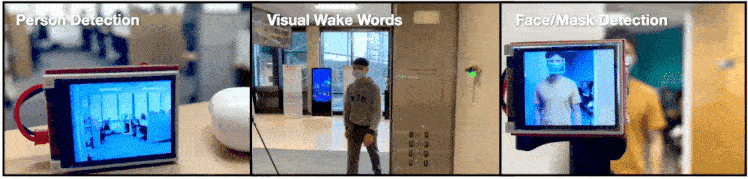

Microcontrollers (MCU) are low-cost, low-power hardware. They are widely deployed and have wide applications.

MCUNet is a system-algorithm co-design framework for tiny deep learning on microcontrollers. It consists of TinyNAS and TinyEngine. They are co-designed to fit the tight memory budgets.

With system-algorithm co-design, we can significantly improve the deep learning performance on the same tiny memory budget.

# Setup Datahub

In [1]:
!conda create --prefix $HOME/my_graphviz graphviz -y

Retrieving notices: ...working... done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.3.0
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/juz063/my_graphviz

  added / updated specs:
    - graphviz


The following NEW packages will be INSTALLED:

  _libgcc_mutex      conda-forge/linux-64::_libgcc_mutex-0.1-conda_forge 
  _openmp_mutex      conda-forge/linux-64::_openmp_mutex-4.5-2_gnu 
  adwaita-icon-theme conda-forge/noarch::adwaita-icon-theme-49.0-unix_0 
  at-spi2-atk        conda-forge/linux-64::at-spi2-atk-2.38.0-h0630a04_3 
  at-spi2-core       conda-forge/linux-64::at-spi2-core-2.40.3-h0630a04_0 
  atk-1.0            conda-forge/linux-64::atk-1.0-2.38.0-h04ea711_2 
  bzip2              conda-forge/linux-64::bzip2-1.0.8-hda65f42_8 
  ca-certificates    conda-forge/noarch:

In [2]:
import os

# Get the path to your home directory
home_dir = os.environ['HOME']

# Construct the path to the bin folder we just created
graphviz_bin_path = os.path.join(home_dir, 'my_graphviz', 'bin')

# Add this path to the system PATH variable for this session
os.environ["PATH"] += os.pathsep + graphviz_bin_path

# Verify it works
!dot -V

dot - graphviz version 14.1.2 (20260126.1125)


In [3]:
# Install earlier release of matplotlib
# Make sure to restart kernel after this installation
!pip install matplotlib==3.1.0
# Install mcunet for pretrained models
!pip install git+https://github.com/soheilzi/mcunet
# Download TinyEngine library for deployment
!wget -O tinyengine.zip "https://hanlab18.mit.edu/files/course/labs/tinyengine.zip"
!unzip -o tinyengine.zip
!mv tinyengine/code_generator .

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/soheilzi/mcunet to /tmp/pip-req-build-ifa8vyad
  Running command git clone --filter=blob:none --quiet https://github.com/soheilzi/mcunet /tmp/pip-req-build-ifa8vyad
  Resolved https://github.com/soheilzi/mcunet to commit e4bdc663c2b66852f480dcf33d22aa671c2287dc
  Preparing metadata (setup.py) ... done
  Created wheel for mcunet: filename=mcunet-0.1.1+202602062344-py3-none-any.whl size=40443 sha256=9beac6c0375b075356770830220662abebf4028f566cad2ffa3f40e2a702b460
  Stored in directory: /tmp/pip-ephem-wheel-cache-osw7hzl8/wheels/13/d6/19/cb12a658a443c880997030b02035c67356d75fc9e66ae3f56b
Successfully built mcunet
  Attempting uninstall: mcunet
    Found existing installation: mcunet 0.1.1+202602052110
    Uninstalling mcunet-0.1.1+202602052110:
      Successfully uninstalled mcunet-0.1.1+202602052110
--2026

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

In [5]:
from mcunet.model_zoo import build_model, download_tflite
from code_generator.CodegenUtilTFlite import GenerateSourceFilesFromTFlite

In [6]:
torch.manual_seed(42)

### Download a pretrained VWW (Visual Wake Word) model
Let's download the `mcunet-320kb-1mb_imagenet` pretrained model from mcuent. This model will later be deployed in the MCU. You can also download the model from [here](https://hanlab.mit.edu/files/course/labs/lab4/mcunet-5fps_vww.tflite).

Visual Wake Words is a common microcontroller vision use-case for identifying whether a person is present in the image or not, and provides a realistic benchmark for tiny vision models.

Please refer to the [model zoo](https://github.com/mit-han-lab/mcunet#model-list) of mcunet for more detailed statistics of the model.



In [7]:
model, image_size, description = build_model(net_id="mcunet-in3", pretrained=True)
tflite_path = download_tflite(net_id="mcunet-in3")

# Setup Google Colab

Install the required package and import necessary libraries.

In [ ]:
# Install earlier release of matplotlib
# Make sure to restart kernel after this installation
!pip install matplotlib
# Install mcunet for pretrained models
!pip install git+https://github.com/soheilzi/mcunet
# Download TinyEngine library for deployment
!wget -O tinyengine.zip "https://hanlab18.mit.edu/files/course/labs/tinyengine.zip"
!unzip -o tinyengine.zip
!mv tinyengine/code_generator .

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

In [ ]:
from mcunet.model_zoo import build_model, download_tflite
from code_generator.CodegenUtilTFlite import GenerateSourceFilesFromTFlite
from google.colab import files

Set the seeds to ensure reproducibility of results

In [ ]:
torch.manual_seed(42)

### Download a pretrained VWW (Visual Wake Word) model
Let's download the `mcunet-320kb-1mb_imagenet` pretrained model from mcuent. This model will later be deployed in the MCU. You can also download the model from [here](https://hanlab.mit.edu/files/course/labs/lab4/mcunet-5fps_vww.tflite).

Visual Wake Words is a common microcontroller vision use-case for identifying whether a person is present in the image or not, and provides a realistic benchmark for tiny vision models.

Please refer to the [model zoo](https://github.com/mit-han-lab/mcunet#model-list) of mcunet for more detailed statistics of the model.



In [ ]:
model, image_size, description = build_model(net_id="mcunet-in3", pretrained=True)
tflite_path = download_tflite(net_id="mcunet-in3")
files.download(tflite_path)

# Model visualization


In [8]:
print(tflite_path)

/home/juz063/.torch/mcunet/mcunet-320kb-1mb_imagenet.tflite


In [10]:
import shutil
from IPython.display import FileLink

# 1. ファイルを作業ディレクトリにコピー
original_path = '/home/juz063/.torch/mcunet/mcunet-320kb-1mb_imagenet.tflite'
target_path = 'mcunet-in3.tflite'
shutil.copyfile(original_path, target_path)

# 2. コピーしたファイルへのリンクを表示
display(FileLink(target_path))

/home/juz063/private/ECE 226/lab3/mcunet-in3.tflite

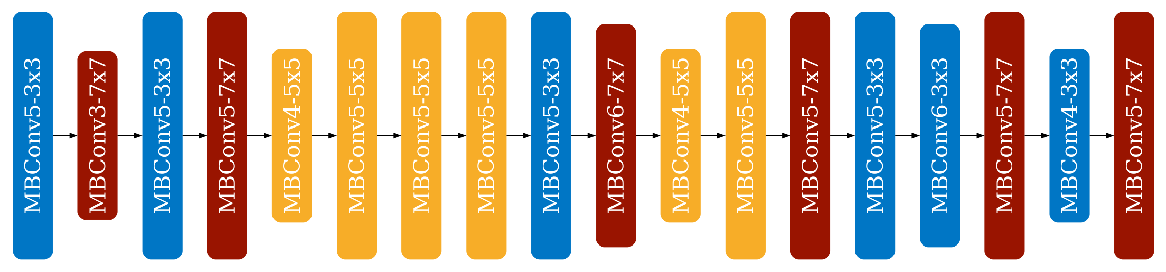

In [9]:
from tinyengine.arch_visualization_helper import visualize_model
visualize_model(model)

To further investigate the vww model, we can use Netron, a cross-platform tool, to visualizing layer-wise information.

1.   Visualize the downloaded model through [Netron](https://github.com/lutzroeder/netron). You can either install it locally or use their [browser version](https://netron.app/).
2.   In Netron, click `Open Model...` to visualize the model downloaded to your PC.

After opening the model with Netron, you can explore the model in great detail. For example, you can see the information of properties, attributes, inputs, and outputs of a convolution layer by clicking the node as below.

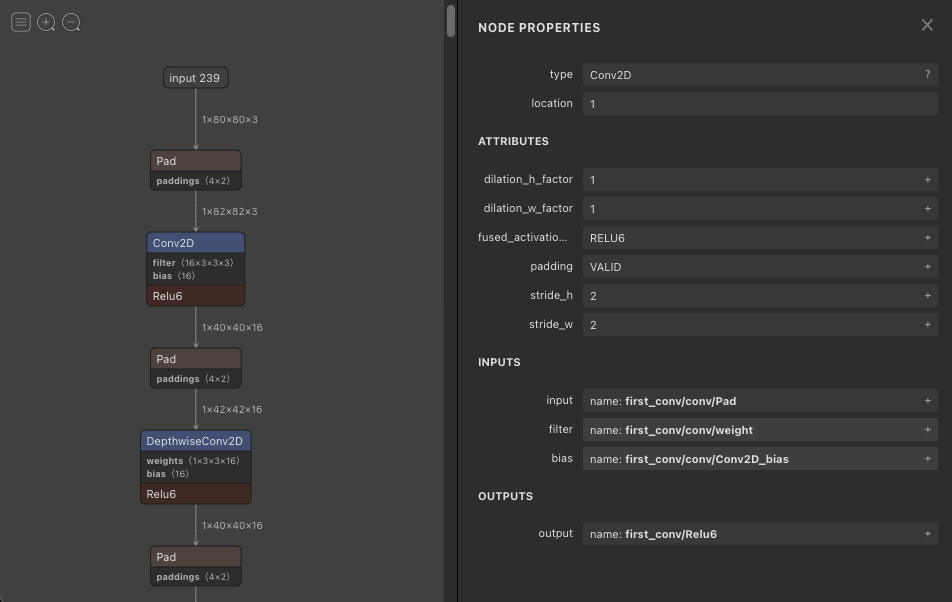




## Question 1: Neural Architecture (10pts)

How many depthwise and pointwise convolution layers (1x1) are there in the `mcunet-320kb-1mb_imagenet` model? Please refer to the visualization result from Netron.

In [11]:
import torch.nn as nn

dw_count = 0
pw_count = 0

# モデルの全レイヤーをループで確認
for m in model.modules():
    if isinstance(m, nn.Conv2d):
        # Depthwiseの判定: groupsが入力チャネル数と同じ
        if m.groups == m.in_channels and m.in_channels > 1:
            dw_count += 1
        # Pointwiseの判定: カーネルサイズが 1x1
        elif m.kernel_size == (1, 1):
            pw_count += 1

print(f"Number of depthwise convolution layers: {dw_count}")
print(f"Number of pointwise convolution layers: {pw_count}")

Number of depthwise convolution layers: 18
Number of pointwise convolution layers: 35


**Your Answer:**
1. Number of depthwise conlution layers: 18
   
2. Number of pointwise convolution layers: 35

   

# Deployment with TinyEngine



Introduction of TinyEngine, a memory-efficient inference library. TinyEngine adapts the memory scheduling according to the overall network topology rather than layer-wise optimization, reducing the memory usage and accelerating the inference. It outperforms existing inference libraries such as TF-Lite Micro from Google and CMSIS-NN from ARM.

TinyEngine adopts the folloing optimization techniques to acclerate infernece and minmize memory footprint.

*   [**Loop reordering**](https://xilinx.github.io/Vitis_Accel_Examples/2019.2/html/loop_reorder.html): A loop transformation technique that attempts to optimize a program's execution speed by reordering/interchanging the sequence of loops.
*   [**Loop unrolling**](https://en.wikipedia.org/wiki/Loop_unrolling): A loop transformation technique that attempts to optimize a program's execution speed at the expense of its binary size, which is an approach known as space-time tradeoff.
*   [**SIMD (Single instruction, multiple data) instructions**](https://en.wikipedia.org/wiki/Single_instruction,_multiple_data): A computing method that enables processing of multiple data with a single instruction.
*   [**Image to Column (Im2col) convolution**](https://iq.opengenus.org/im2col/): An implementation technique of computing convolution operation using general matrix multiplication (GEMM) operations.
*   [**HWC to CHW weight format transformation**](https://oneapi-src.github.io/oneDNN/dev_guide_understanding_memory_formats.html): A weight format transformation technique that increases cache hit ratio for in-place depth-wise convolution.
*   [**In-place depth-wise convolution**](https://mcunet.mit.edu/#mcunetv1): A unique data placement technique for depth-wise convolution that overwrites input data by intermediate/output data to reduce peak SRAM memory.

Please refer to the TinyEngine [GitHub](https://github.com/mit-han-lab/tinyengine) and the MCUNet [website](https://mcunet.mit.edu/) for more information.



Now we will generate C source files for the model using TinyEngine for on-device deployment. You can change the `optimization_config` to turn on/off optimization techniques.

TinyEngine derives the memory schedules for each activation tensor. It will output the number of activation tensors and memory footprint as a figure for visualization.




Deriving the memory schedule for 50 activation tensors.


100%|██████████| 50/50 [00:00<00:00, 115164.85it/s]


---------------- Operator-Tensor Mapping ----------------
 #op |   operator type   | input tensor | output tensor |
#0   |CONV_2D            |0             |1              |
#1   |DEPTHWISE_CONV_2D  |1             |1              |
#2   |CONV_2D            |1             |2              |
#3   |CONV_2D            |2             |3              |
#4   |DEPTHWISE_CONV_2D  |3             |3              |
#5   |CONV_2D            |3             |4              |
#6   |CONV_2D            |4             |5              |
#7   |DEPTHWISE_CONV_2D  |5             |5              |
#8   |CONV_2D            |5             |6              |
#9   |ADD                |6,4           |7              |
#10  |CONV_2D            |7             |8              |
#11  |DEPTHWISE_CONV_2D  |8             |8              |
#12  |CONV_2D            |8             |9              |
#13  |ADD                |9,7           |10             |
#14  |CONV_2D            |10            |11             |
#15  |DEPTHWIS

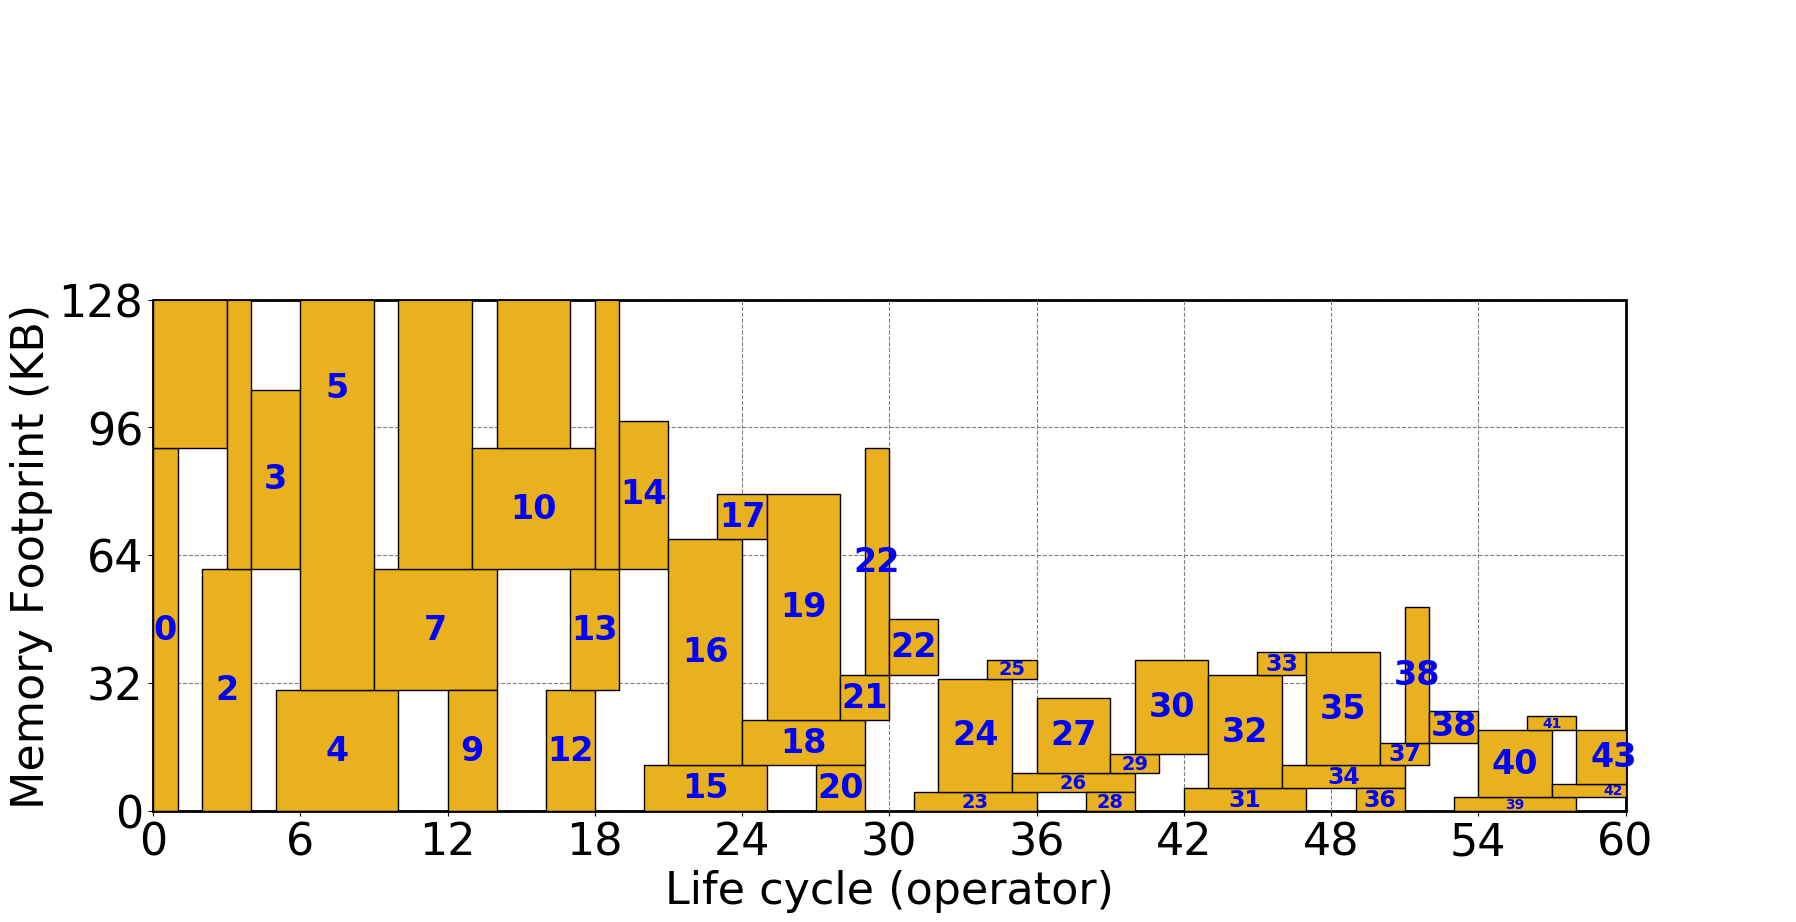

In [10]:
############### YOUR CODE STARTS HERE ###############
optimization_config = {
    "loop_reordering": True, # Enable loop reordering optimization
    "im2col": True, # Enable im2col convolution
    "hwc2chw_weight": True, # Enable HWC -> CHW format transformation for weights
    "loop_unrolling": True, # Enable loop unrolling optimization
    "simd": True, # Enable SIMD programming
    "inplace_depthwise": True, # Enable inplace depthwise convolution
}
############### YOUR CODE ENDS HERE ###############
tensor_lfe_cycle_path = "./lifecycle.png"
peakmem = GenerateSourceFilesFromTFlite(
    tflite_path,
    life_cycle_path=tensor_lfe_cycle_path,
    custom_optimization_config=optimization_config,
)
print(f"Peak memory: {peakmem} bytes")

## Question 2: Memory Reduction of In-place Depthwise Convolution (20pts)

Please change the `optimization_config` to enable/disable in-place depthwise convolution and evaluate the memory reduction from in-place depthwise convolution.

### Question 2.1: Peak Memory (10pt)

What are peak memory and number of activation tensors before and after enabling in-place depthwise update?

**Your Answer:**

Before enabling in-place depthwise update, the peak memory is: 418176 bytes

After enabling in-place depthwise update, the peak memory is: 247808 bytes

Before enabling in-place depthwise update, the number of activation tensors is: 68

After enabling in-place depthwise update, the number of activation tensors is: 50

Deriving the memory schedule for 68 activation tensors.


100%|██████████| 68/68 [00:00<00:00, 46466.71it/s]


---------------- Operator-Tensor Mapping ----------------
 #op |   operator type   | input tensor | output tensor |
#0   |CONV_2D            |0             |1              |
#1   |DEPTHWISE_CONV_2D  |1             |2              |
#2   |CONV_2D            |2             |3              |
#3   |CONV_2D            |3             |4              |
#4   |DEPTHWISE_CONV_2D  |4             |5              |
#5   |CONV_2D            |5             |6              |
#6   |CONV_2D            |6             |7              |
#7   |DEPTHWISE_CONV_2D  |7             |8              |
#8   |CONV_2D            |8             |9              |
#9   |ADD                |9,6           |10             |
#10  |CONV_2D            |10            |11             |
#11  |DEPTHWISE_CONV_2D  |11            |12             |
#12  |CONV_2D            |12            |13             |
#13  |ADD                |13,10         |14             |
#14  |CONV_2D            |14            |15             |
#15  |DEPTHWIS

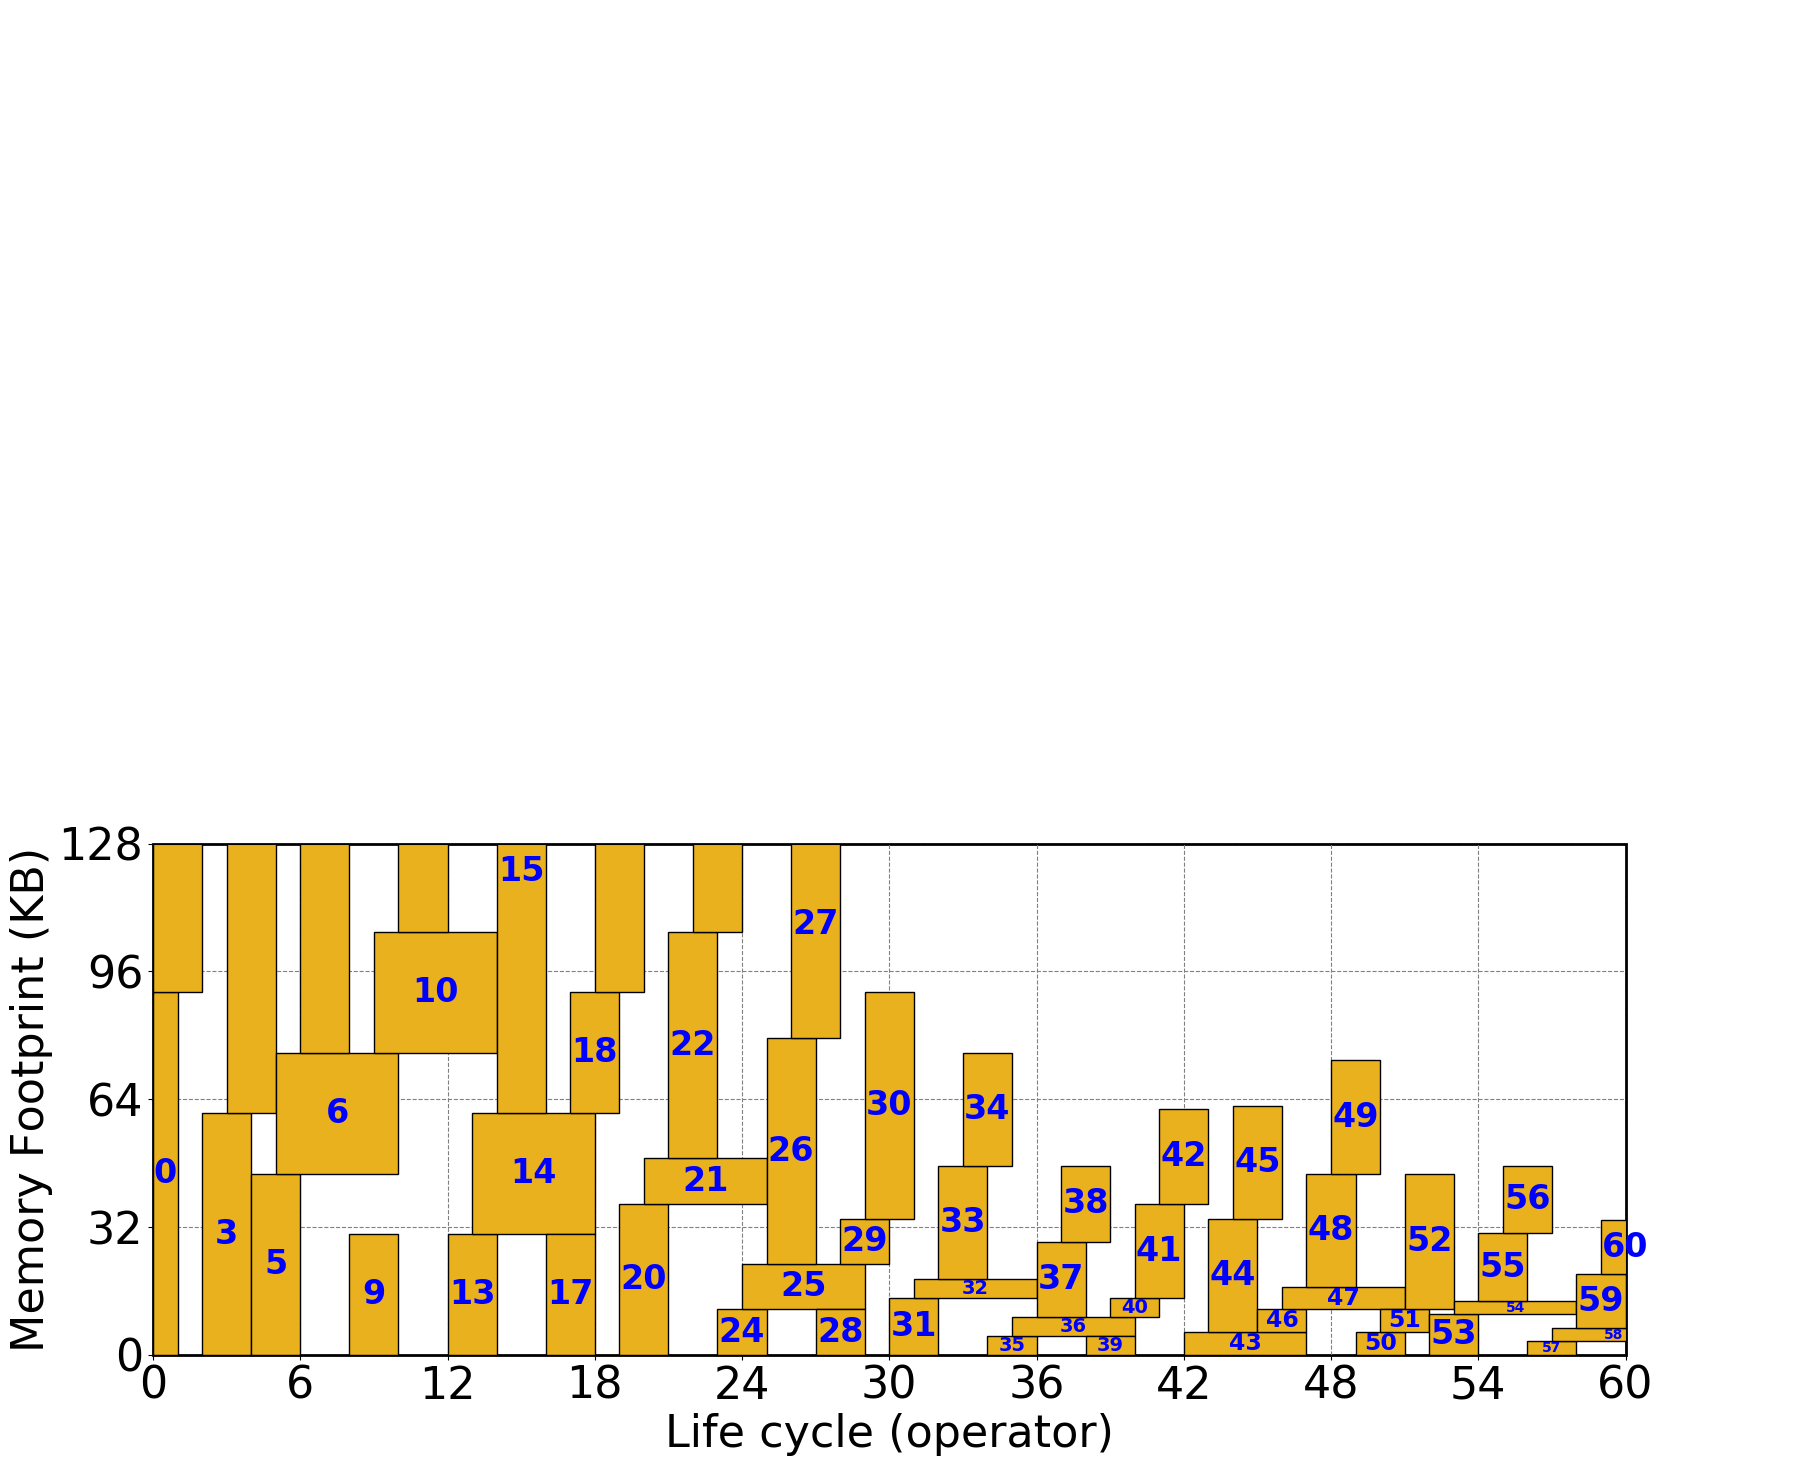

In [12]:
############### YOUR CODE STARTS HERE ###############
optimization_config = {
    "loop_reordering": True, # Enable loop reordering optimization
    "im2col": True, # Enable im2col convolution
    "hwc2chw_weight": True, # Enable HWC -> CHW format transformation for weights
    "loop_unrolling": True, # Enable loop unrolling optimization
    "simd": True, # Enable SIMD programming
    "inplace_depthwise": False, # Enable inplace depthwise convolution
}
############### YOUR CODE ENDS HERE ###############
tensor_lfe_cycle_path = "./lifecycle.png"
peakmem = GenerateSourceFilesFromTFlite(
    tflite_path,
    life_cycle_path=tensor_lfe_cycle_path,
    custom_optimization_config=optimization_config,
)
print(f"Peak memory: {peakmem} bytes")

### Question 2.2: Memory Bottleneck (10pt)

Which tensor leads to the memory bottleneck before and after enabling in-place depthwise update? Please specify its tensor id.

**Your Answer:**

Before enabling in-place depthwise update, the memory bottleneck tensor is: 15

After enabling in-place depthwise update, the memory bottleneck tensor is: 5

##Let's learn how the optimization techniques are realized in Tiny Inference Engine.

Nomenclature of the files linked in Q3 is as follows.
For example, `convolve_1x1_s8.c` indicates it is a pointwise (1x1 kernel size) convolution operator, and `depthwise_kernel3x3_stride1_inplace_CHW.c` indicates it is a depthwise convolution operator with 3x3 kernel size and stride 1.

Take `convolve_1x1_s8_fpreq.c` as an example, which is linked in Q3.1. In this file, you will find that we use multiple "[macros](https://www.programiz.com/c-programming/c-preprocessor-macros)" to switch on/off different optimization techniques. For instance, it will execute Lines 36-61 when `loop_reordering` is set as False.

Please review the optimization techniques introduced in the Lectures and further look at the code files linked in questions below to learn how the optimization techniques are realized and why the speed/memory footprint can be improved in Tiny Inference Engine.

In [ ]:
# The following code snippet is for demonstration and not runnable on Colab / datahub
#if (!LOOP_REORDERING)
  /* Similar to TF-Lite Implementation */
	for (int out_y = 0; out_y < output_y; ++out_y) {
		for (int out_x = 0; out_x < output_x; ++out_x) {
			for (int out_channel = 0; out_channel < output_ch; ++out_channel) {
				int32_t sum = 0;
				for (int filter_y = 0; filter_y < DIM_KER_Y; ++filter_y) {
					for (int filter_x = 0; filter_x < DIM_KER_X; ++filter_x) {
						for (int in_channel = 0; in_channel < input_ch; ++in_channel) {
							int32_t input_val = input[Offset(input_y, input_x, input_ch, 0, out_y, out_x, in_channel)];
							int32_t filter_val = kernel[Offset(DIM_KER_Y, DIM_KER_X, input_ch, out_channel, filter_y, filter_x, in_channel)];
							sum += filter_val * (input_val + input_offset);
						}
					}
				}                      #実行するな！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！

				if (bias) {
					sum += bias[out_channel];
				}
				sum = (int32_t) ((float)sum * scales[out_channel]);
				sum += out_offset;
				sum = MAX(sum, out_activation_min);
				sum = MIN(sum, out_activation_max);

				output[Offset(output_y, output_x, output_ch, 0, out_y, out_x, out_channel)] = (int8_t)(sum);
			}
		}
	}

## Question 3: Please read the code files linked in the questions and answer following questions. (35pts)

Hint: The source code uses `#if`, `#elif`, and `#endif` to control which portions of the source file are compiled. More detailed information can be found [here](https://docs.microsoft.com/en-us/cpp/preprocessor/hash-if-hash-elif-hash-else-and-hash-endif-directives-c-cpp?view=msvc-170).

### Question 3.1:  In [convolve_1x1_s8_fpreq.c](https://hanlab.mit.edu/files/course/labs/lab4/convolve_1x1_s8_fpreq.c), which part of the code (Lines) will be executed when we only enable `loop_reordering`, `loop_unrolling` and `simd`? (8pt)

**Your Answer:**

### Question 3.2:  In [depthwise_kernel3x3_stride1_inplace_CHW_fpreq.c](https://hanlab.mit.edu/files/course/labs/lab4/depthwise_kernel3x3_stride1_inplace_CHW_fpreq.c), which part of the code (Lines) will be executed when we only enable `loop_reordering`, `im2col`, `hwc2chw_weight`, `loop_unrolling` and `inplace_depthwise`? (9pt)

**Your Answer:**

### Question 3.3: In [convolve_1x1_s8_ch48_fpreq.c](https://hanlab.mit.edu/files/course/labs/lab4/convolve_1x1_s8_ch48_fpreq.c), which part of the code (Lines) will be executed when we only enable `loop_reordering` and `loop_unrolling`? (9pt)


**Your Answer:**

### Question 3.4: In [depthwise_kernel7x7_stride2_inplace_CHW_fpreq.c](https://hanlab.mit.edu/files/course/labs/lab4/depthwise_kernel7x7_stride2_inplace_CHW_fpreq.c), which part of the code (Lines) will be executed when we only enable `loop_reordering`, `im2col` and `hwc2chw_weight`? (9pt)


**Your Answer:**

# Knowledge Distillation


We will use Resnet18 as teacher and student models and CIFAR-10 dataset for this section of the lab.

Load the pretrained model and the CIFAR-10 dataset

In [14]:
# Define the teacher model
teacher_model = resnet18(pretrained=True)
teacher_model.fc = nn.Linear(512, 10)  # Modify the last layer for your task

# Define the student model
student_model = resnet18()
student_model.fc = nn.Linear(512, 10)  # Modify the last layer for your task

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.SGD(student_model.parameters(), lr=0.001, momentum=0.9)

# Define the data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Load the CIFAR-10 dataset
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Files already downloaded and verified


## Question 4 (20 pts)

Please complete the following code for:


*   Teacher model
*   Distillation Loss function
*   Student model with knowledge distillation
*   Student model without knowledge distillation





In [13]:
# 先生モデル（teacher_model）を更新するためのオプティマイザを定義
optimizer_teacher = optim.SGD(teacher_model.parameters(), lr=0.001, momentum=0.9)

# デバイスの設定（GPUが使えるならcuda、そうでないならcpu）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# モデルをGPUへ転送
teacher_model.to(device)
student_model.to(device)

# Train the teacher model (fine-tuning)
for epoch in range(5):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)##

      ### Your code starts here! ###

        optimizer_teacher.zero_grad() # 勾配のリセット
        outputs = teacher_model(inputs) # 予測
        loss = criterion(outputs, labels) # 損失計算
        loss.backward() # 逆伝播
        optimizer_teacher.step() # 重み更新
        running_loss += loss.item()

      ### Your code ends here! ###

    print(f'Teacher Model - Epoch: {epoch+1}, Loss: {running_loss/len(train_loader)}')

# Define the distillation loss function
def distillation_loss(outputs, labels, teacher_outputs, temperature):

  # Hint: Use Softmax function
  ### Your code starts here! ###

    # ソフトターゲットの計算（KLダイバージェンスを使用）
    # Tで割ることで確率分布をなだらかにする
    soft_targets = nn.functional.softmax(teacher_outputs / temperature, dim=1)
    soft_prob = nn.functional.log_softmax(outputs / temperature, dim=1)
    
    # 蒸留損失（KLダイバージェンス）と通常の損失（CrossEntropy）の組み合わせ
    distillation_loss = nn.functional.kl_div(soft_prob, soft_targets, reduction='batchmean') * (temperature**2)
    student_loss = nn.functional.cross_entropy(outputs, labels)
    
    return distillation_loss + student_loss

  ### Your code ends here! ###

# Train the student model with knowledge distillation
temperature = 3
for epoch in range(5):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)##

      ### Your code starts here! ###

        optimizer.zero_grad()
        with torch.no_grad():
            teacher_outputs = teacher_model(inputs) # 教師の予測（勾配不要）
            
        student_outputs = student_model(inputs) # 生徒の予測
        loss = distillation_loss(student_outputs, labels, teacher_outputs, temperature)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

      ### Your code ends here! ###

    print(f'Student Model (with Distillation) - Epoch: {epoch+1}, Loss: {running_loss/len(train_loader)}')

# Train the student model from scratch (without distillation)
student_model_scratch = resnet18().to(device)
student_model_scratch.fc = nn.Linear(512, 10).to(device)
optimizer_scratch = optim.SGD(student_model_scratch.parameters(), lr=0.001, momentum=0.9)

optimizer = optim.SGD(student_model.parameters(), lr=0.001, momentum=0.9)
for epoch in range(5):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)##

      ### Your code starts here! ###

        optimizer_scratch.zero_grad()
        outputs = student_model_scratch(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_scratch.step()
        running_loss += loss.item()

      ### Your code ends here! ###

    print(f'Student Model (without Distillation) - - Epoch: {epoch+1}, Loss: {running_loss/len(train_loader)}')


Using device: cuda
Teacher Model - Epoch: 1, Loss: 1.043447187108457
Teacher Model - Epoch: 2, Loss: 0.6375259773048294
Teacher Model - Epoch: 3, Loss: 0.49024345615254644
Teacher Model - Epoch: 4, Loss: 0.3768577087870644
Teacher Model - Epoch: 5, Loss: 0.29495086286531386
Student Model (with Distillation) - Epoch: 1, Loss: 5.9351271586040095
Student Model (with Distillation) - Epoch: 2, Loss: 3.796559873444345
Student Model (with Distillation) - Epoch: 3, Loss: 2.933170591931209
Student Model (with Distillation) - Epoch: 4, Loss: 2.3748491885107192
Student Model (with Distillation) - Epoch: 5, Loss: 1.9777065288380284
Student Model (without Distillation) - - Epoch: 1, Loss: 1.6005638177742434
Student Model (without Distillation) - - Epoch: 2, Loss: 1.2395725725099558
Student Model (without Distillation) - - Epoch: 3, Loss: 1.0401355215655568
Student Model (without Distillation) - - Epoch: 4, Loss: 0.882228986991336
Student Model (without Distillation) - - Epoch: 5, Loss: 0.7428945080

In [15]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# 1. テスト用データの読み込み (train=False にするのがポイント)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform)

# 2. テスト用データローダーの作成
# テスト時はデータを混ぜる必要がないので shuffle=False にします
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("test_loader is ready")

Files already downloaded and verified
test_loader is ready


In [16]:
def get_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# 各モデルの精度を計算
acc_dist = get_accuracy(student_model, test_loader) # 蒸留あり
acc_scratch = get_accuracy(student_model_scratch, test_loader) # 独学

print(f'Accuracy - Student (With Distillation): {acc_dist:.2f}%')
print(f'Accuracy - Student (Without Distillation): {acc_scratch:.2f}%')

Accuracy - Student (With Distillation): 72.47%
Accuracy - Student (Without Distillation): 62.95%


In [15]:
# 先生モデル（teacher_model）を更新するためのオプティマイザを定義
optimizer_teacher = optim.SGD(teacher_model.parameters(), lr=0.001, momentum=0.9)

# デバイスの設定（GPUが使えるならcuda、そうでないならcpu）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# モデルをGPUへ転送
teacher_model.to(device)
student_model.to(device)

# Train the teacher model (fine-tuning)
for epoch in range(10):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)##

      ### Your code starts here! ###

        optimizer_teacher.zero_grad() # 勾配のリセット
        outputs = teacher_model(inputs) # 予測
        loss = criterion(outputs, labels) # 損失計算
        loss.backward() # 逆伝播
        optimizer_teacher.step() # 重み更新
        running_loss += loss.item()

      ### Your code ends here! ###

    print(f'Teacher Model - Epoch: {epoch+1}, Loss: {running_loss/len(train_loader)}')

# Define the distillation loss function
def distillation_loss(outputs, labels, teacher_outputs, temperature):

  # Hint: Use Softmax function
  ### Your code starts here! ###

    # ソフトターゲットの計算（KLダイバージェンスを使用）
    # Tで割ることで確率分布をなだらかにする
    soft_targets = nn.functional.softmax(teacher_outputs / temperature, dim=1)
    soft_prob = nn.functional.log_softmax(outputs / temperature, dim=1)
    
    # 蒸留損失（KLダイバージェンス）と通常の損失（CrossEntropy）の組み合わせ
    distillation_loss = nn.functional.kl_div(soft_prob, soft_targets, reduction='batchmean') * (temperature**2)
    student_loss = nn.functional.cross_entropy(outputs, labels)
    
    return distillation_loss + student_loss

  ### Your code ends here! ###

# Train the student model with knowledge distillation
temperature = 3
for epoch in range(10):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)##

      ### Your code starts here! ###

        optimizer.zero_grad()
        with torch.no_grad():
            teacher_outputs = teacher_model(inputs) # 教師の予測（勾配不要）
            
        student_outputs = student_model(inputs) # 生徒の予測
        loss = distillation_loss(student_outputs, labels, teacher_outputs, temperature)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

      ### Your code ends here! ###

    print(f'Student Model (with Distillation) - Epoch: {epoch+1}, Loss: {running_loss/len(train_loader)}')

# Train the student model from scratch (without distillation)
student_model_scratch = resnet18().to(device)
student_model_scratch.fc = nn.Linear(512, 10).to(device)
optimizer_scratch = optim.SGD(student_model_scratch.parameters(), lr=0.001, momentum=0.9)

optimizer = optim.SGD(student_model.parameters(), lr=0.001, momentum=0.9)
for epoch in range(10):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)##

      ### Your code starts here! ###

        optimizer_scratch.zero_grad()
        outputs = student_model_scratch(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_scratch.step()
        running_loss += loss.item()

      ### Your code ends here! ###

    print(f'Student Model (without Distillation) - - Epoch: {epoch+1}, Loss: {running_loss/len(train_loader)}')


Using device: cuda
Teacher Model - Epoch: 1, Loss: 1.0443064770125368
Teacher Model - Epoch: 2, Loss: 0.6407748402079658
Teacher Model - Epoch: 3, Loss: 0.4866020197186933
Teacher Model - Epoch: 4, Loss: 0.38177962662161463
Teacher Model - Epoch: 5, Loss: 0.2922048602358002
Teacher Model - Epoch: 6, Loss: 0.23401014677360846
Teacher Model - Epoch: 7, Loss: 0.18260346990450263
Teacher Model - Epoch: 8, Loss: 0.14374888869231123
Teacher Model - Epoch: 9, Loss: 0.1174913802317551
Teacher Model - Epoch: 10, Loss: 0.10138644014730516
Student Model (with Distillation) - Epoch: 1, Loss: 8.808547500454251
Student Model (with Distillation) - Epoch: 2, Loss: 5.83906434716471
Student Model (with Distillation) - Epoch: 3, Loss: 4.589060132155943
Student Model (with Distillation) - Epoch: 4, Loss: 3.7546305232645607
Student Model (with Distillation) - Epoch: 5, Loss: 3.1088152110119305
Student Model (with Distillation) - Epoch: 6, Loss: 2.5569587012995845
Student Model (with Distillation) - Epoch: 

In [16]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("test_loader is ready")

Files already downloaded and verified
test_loader is ready


In [17]:
def get_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

acc_dist = get_accuracy(student_model, test_loader) # 蒸留あり
acc_scratch = get_accuracy(student_model_scratch, test_loader) # 独学

print(f'Accuracy - Student (With Distillation): {acc_dist:.2f}%')
print(f'Accuracy - Student (Without Distillation): {acc_scratch:.2f}%')

Accuracy - Student (With Distillation): 75.32%
Accuracy - Student (Without Distillation): 64.36%


## Question 5 (15 pts)

The last code cell performs training of student models with and without knowledge distillation.

Given this observation, please answer the following questions.

### Question 5.1 (5 pts)

How is the performance of student model with knowledge distillation compared to without distillation? Analyze their loss values over epochs and discuss the impact of knowledge distillation on model training.

**Your Answer:**
The student model with knowledge distillation significantly outperforms the one without, achieving a test accuracy of 72.47% compared to 62.95%. Although the distillation-based training shows higher absolute loss values (1.97 vs. 0.74 after 5 epochs), this is due to the additional distillation loss term that aligns the student with the teacher's soft targets. The substantial 9.52% accuracy gain demonstrates that transferring "dark knowledge" from the teacher—which attained a low loss of 0.29—provides a richer supervisory signal than hard labels alone. This process effectively guides the student to learn more complex feature representations and improve its generalization capabilities on unseen data.

### Question 5.2 (5 pts)

What is the role of the distillation loss function in knowledge distillation? How does it differ from the standard cross-entropy loss function?

**Your Answer:**
The role of the distillation loss function is to transfer "dark knowledge" from the teacher to the student by minimizing the divergence between their soft probability distributions. Unlike the standard cross-entropy loss, which uses hard labels (1 for correct, 0 for incorrect) to provide binary supervision, the distillation loss utilizes soft targets smoothed by a temperature parameter $T$. This allows the student to learn not only the correct class but also the complex correlations between different classes as perceived by the teacher model.

### Question 5.3 (5 pts)

Does increasing the number of epochs to 10 bring a difference in performance of student models with and without knowledge distillation? If so, analyze and discuss the difference in performance of the models in detail.

**Your Answer:**
Increasing the number of epochs to 10 widens the performance gap between the two student models, with the test accuracy difference growing from 9.52% at epoch 5 to 10.96% at epoch 10. While both models improved their performance over time, the student model with knowledge distillation reached a significantly higher accuracy of 75.32%, compared to 64.36% for the baseline. This indicates that the "dark knowledge" provided by the teacher model—which itself reached a very low loss of 0.10—does not just accelerate early learning but continues to provide a more effective optimization guide during extended training. The model without distillation appears to hit a performance ceiling much earlier, whereas the distilled model leverages the teacher's soft targets to refine its feature representations more deeply without overfitting to hard labels.